# Taller de Feature Engineering: Seleccion y creacion de variables

**Bootcamp:** Python - PY4
**Modulo:** Machine Learning Avanzado y Feature Engineering.

## De que trata esta sesion

Antes de mejorar un modelo, necesitamos saber donde estamos parados. En esta primera sesion vamos a:

1. Cargar el dataset que vamos a usar durante todo el taller (Bike Sharing Demand).
2. Hacer una exploracion rapida de los datos (sin limpieza profunda todavia).
3. Entrenar un modelo baseline con Linear Regression.
4. Registrar las metricas iniciales (RMSE y R2).

Estas metricas del baseline son nuestro punto de comparacion. En la sesion 2 vamos a aplicar tecnicas de feature engineering y en la sesion 3 vamos a optimizar el modelo y comparar contra este baseline. Si no sabemos de donde partimos, no vamos a poder medir si las mejoras realmente funcionan.

## El dataset: Bike Sharing Demand

Vamos a trabajar con datos de un sistema de bicicletas compartidas en Washington D.C. (Capital Bikeshare). Cada fila representa una hora especifica de un dia, con informacion del clima y la cantidad de bicicletas rentadas en esa hora.

Nuestra variable objetivo (target) va a ser `cnt`: el numero total de bicicletas rentadas en esa hora. Como es una variable numerica continua, este es un problema de **regresion**.


## Paso 1: Configuracion del entorno

Antes de trabajar con los datos, importamos las librerias que vamos a necesitar durante toda la sesion:

- `pandas` y `numpy` para manejo de datos.
- `matplotlib` y `seaborn` para visualizacion.
- `scikit-learn` para el modelo y las metricas.

Tambien fijamos una semilla aleatoria (`random_state`) para que los resultados sean reproducibles cada vez que corramos el notebook.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

RANDOM_STATE = 42

sns.set_style("white")


## Paso 2: Carga del dataset

Vamos a cargar el dataset directamente desde GitHub, asi no necesitamos descargar ningun archivo de forma manual. El archivo se llama `hour.csv` porque cada fila corresponde a una hora especifica (hay otra version `day.csv` agregada por dia, que no vamos a usar).


In [ ]:
URL = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Module_02_machine_learning_and_feature_engineering/datasets/bikeshare_Washington.csv"

df = pd.read_csv(URL)
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Revisemos rapido cuantas filas y columnas tiene el dataset, y que tipo de dato tiene cada columna.


In [ ]:
print("Filas y columnas:", df.shape)
df.info()


Filas y columnas: (17520, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17520 non-null  int64  
 1   dteday      17520 non-null  object 
 2   season      17520 non-null  int64  
 3   yr          17520 non-null  int64  
 4   mnth        17520 non-null  int64  
 5   hr          17520 non-null  int64  
 6   holiday     17520 non-null  int64  
 7   weekday     17520 non-null  int64  
 8   workingday  17520 non-null  int64  
 9   weathersit  17520 non-null  int64  
 10  temp        17520 non-null  float64
 11  atemp       17520 non-null  float64
 12  hum         17520 non-null  float64
 13  windspeed   17520 non-null  float64
 14  casual      17520 non-null  int64  
 15  registered  17520 non-null  int64  
 16  cnt         17520 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


### Diccionario de columnas

Para no perdernos, este es el significado de cada columna:

- `instant`: indice de registro (no aporta informacion util para el modelo).
- `dteday`: fecha.
- `season`: estacion del anio (1: invierno, 2: primavera, 3: verano, 4: otonio).
- `yr`: anio (0: 2011, 1: 2012).
- `mnth`: mes (1 a 12).
- `hr`: hora del dia (0 a 23).
- `holiday`: si el dia es feriado.
- `weekday`: dia de la semana.
- `workingday`: si es un dia laboral (ni feriado ni fin de semana).
- `weathersit`: condicion climatica (1: despejado, 2: nublado/niebla, 3: lluvia/nieve ligera, 4: clima extremo).
- `temp`, `atemp`: temperatura real y sensacion termica, normalizadas entre 0 y 1.
- `hum`: humedad normalizada.
- `windspeed`: velocidad del viento normalizada.
- `casual`: cantidad de usuarios ocasionales (no registrados).
- `registered`: cantidad de usuarios registrados.
- `cnt`: **variable objetivo**. Total de bicicletas rentadas en esa hora (`casual` + `registered`).


## Paso 3: Exploracion rapida de los datos

En esta fase no vamos a hacer limpieza profunda todavia (eso viene en la sesion 2, junto con el feature engineering). Por ahora solo queremos entender la forma general de los datos: si hay valores nulos, como se distribuye el target, y si hay algo raro que debamos tener en cuenta antes de entrenar el baseline.

Primero, revisemos si hay valores nulos.


In [ ]:
df.isnull().sum()


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Ahora veamos algunas estadisticas descriptivas generales de las columnas numericas.


In [ ]:
df.describe()


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,8652.180023,2.494521,0.500000,6.515068,11.500000,0.028767,2.999258,0.683562,1.429224,0.495291,0.474215,0.628025,0.190663,35.395205,152.620205,187.938299
std,5036.025134,1.109442,0.500014,3.449604,6.922384,0.167156,2.004034,0.465099,0.642868,0.193208,0.172492,0.193071,0.122946,49.205358,151.304840,181.447622
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4286.750000,2.000000,0.000000,4.000000,5.750000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,32.000000,38.000000
50%,8645.500000,2.500000,0.500000,7.000000,11.500000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,16.000000,114.000000,140.000000
75%,13015.250000,3.000000,1.000000,10.000000,17.250000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.790000,0.253700,48.000000,219.000000,280.000000
max,17379.000000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


### Distribucion de la variable objetivo

Grafiquemos la distribucion de `cnt` para ver su forma. Esto nos va a servir tambien en la sesion 2, cuando hablemos de log-transform para corregir sesgos en la distribucion.


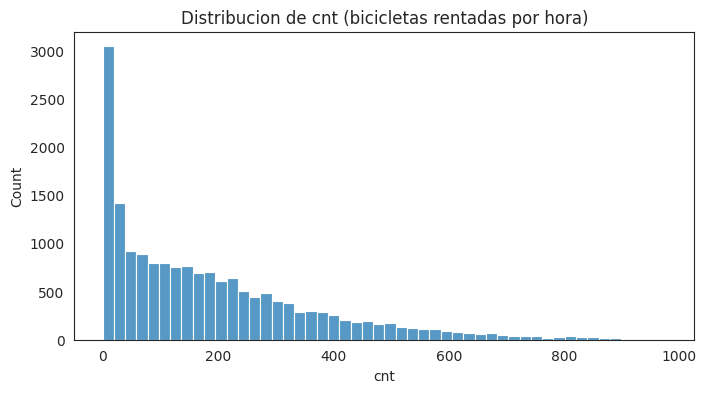

Media: 187.93829908675798
Mediana: 140.0
Sesgo (skew): 1.2819222147164613


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["cnt"], bins=50, ax=ax)
ax.set_title("Distribucion de cnt (bicicletas rentadas por hora)")
ax.set_xlabel("cnt")
plt.show()

print("Media:", df["cnt"].mean())
print("Mediana:", df["cnt"].median())
print("Sesgo (skew):", df["cnt"].skew())


Como pueden ver, la distribucion tiene una cola larga hacia la derecha (hay muchas horas con demanda baja y pocas horas con demanda muy alta). Esto es justamente el tipo de sesgo que vamos a corregir en la sesion 2 con una transformacion logaritmica. Por ahora, para el baseline, la dejamos tal cual.

### Atencion: cuidado con el data leakage

Miremos con atencion las columnas `casual` y `registered`. Si sumamos ambas, obtenemos exactamente `cnt`.


In [ ]:
(df["casual"] + df["registered"]).head()

,0
0,16
1,40
2,32
3,13
4,1


In [ ]:
(df["cnt"]).head()

,cnt
0,16
1,40
2,32
3,13
4,1


Esto es un ejemplo clasico de **data leakage**: si usamos `casual` y `registered` como variables de entrada (features), el modelo no esta aprendiendo nada, simplemente esta sumando dos columnas que ya contienen la respuesta. Por eso, estas dos columnas **no** las vamos a usar como features en ningun momento del taller.

## Paso 4: Preparacion minima para el baseline

Para este primer modelo baseline, no vamos a hacer ingenieria de caracteristicas todavia. Solo vamos a:

1. Descartar columnas que no sirven como features (`instant`, `dteday`, `casual`, `registered`) o que son la propia variable objetivo (`cnt`).
2. Separar el dataset en variables predictoras (`X`) y variable objetivo (`y`).
3. Dividir en conjunto de entrenamiento y de prueba (train/test split).


In [ ]:
features = ["season", "yr", "mnth", "hr", "holiday", "weekday",
            "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]

X = df[features]
y = df["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Tamanio de test set:", X_train.shape)
print("Tamanio de train set:", X_test.shape)


Tamanio de test set: (14016, 12)
Tamanio de train set: (3504, 12)


## Paso 5: Modelo baseline con Regresión Lineal

Ahora entrenamos un modelo baseline usando **Linear Regression**.

La regresión lineal es una excelente referencia inicial porque es un modelo sencillo y fácil de interpretar. Además, depende mucho de la calidad de las variables de entrada, por lo que en la siguiente sesión podremos observar claramente cómo el feature engineering mejora su desempeño.

Más adelante podremos comparar este baseline con modelos más complejos.


In [ ]:
lr_baseline = LinearRegression()

lr_baseline.fit(X_train, y_train)

LinearRegression()

### Evaluacion del baseline

Con el modelo entrenado, generamos predicciones sobre el test set y calculamos dos metricas estandar para problemas de regresion:

- **RMSE** (Root Mean Squared Error): en promedio, cuanto se equivoca el modelo, en las mismas unidades que `cnt`. Cuanto mas bajo, mejor.
- **R2**: que proporcion de la variabilidad de `cnt` explica el modelo. Va de 0 a 1 (mas cercano a 1 es mejor).


In [ ]:
y_pred_baseline = lr_baseline.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"RMSE baseline: {rmse_baseline:.2f}")
print(f"R² baseline: {r2_baseline:.4f}")

RMSE baseline: 136.32
R² baseline: 0.4049


### Visualizando el ajuste del modelo

Un grafico util para revisar que tan bien predice el modelo es comparar los valores reales contra los valores predichos. Si el modelo fuera perfecto, todos los puntos caerian sobre la linea diagonal.


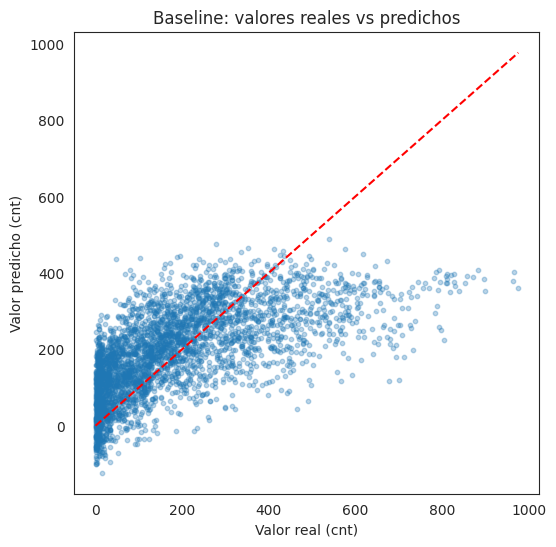

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_baseline, alpha=0.3, s=10)
# Dibuja la línea de referencia y = x (predicción perfecta). Cuanto más cerca estén los puntos de esta línea, mejor será el desempeño del modelo
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
ax.set_xlabel("Valor real (cnt)")
ax.set_ylabel("Valor predicho (cnt)")
ax.set_title("Baseline: valores reales vs predichos")
plt.show()


### Interpretación

Es normal que el desempeño de este modelo baseline sea limitado.

La regresión lineal supone una relación aproximadamente lineal entre las variables predictoras y la demanda de bicicletas. Sin embargo, este problema contiene patrones estacionales, efectos horarios e interacciones entre variables que un modelo lineal simple no puede capturar completamente.

Precisamente por eso, en la siguiente sesión aplicaremos técnicas de feature engineering para construir variables más informativas y evaluar cuánto mejora el desempeño del modelo.

## Paso 6: Registrar las metricas del baseline

Vamos a guardar las metricas del baseline en un diccionario simple. Vamos a necesitar estos numeros en la sesion 3, cuando construyamos la tabla comparativa entre el modelo inicial y el modelo optimizado (Fase 4 del taller).


In [ ]:
resultados = {
    "modelo": "Baseline (Linear Regression, sin feature engineering)",
    "rmse": round(rmse_baseline,3),
    "r2": round(r2_baseline,3)
}

resultados


{'modelo': 'Baseline (Linear Regression, sin feature engineering)',
 'rmse': np.float64(136.319),
 'r2': 0.405}

Guarda estos numeros (o el diccionario `resultados`) en algun lugar seguro, ya que los vamos a comparar en la sesion 3. Una opcion simple es guardarlos en un archivo de texto o CSV:


In [ ]:
pd.DataFrame([resultados]).to_csv("resultados_baseline.csv", index=False)


## Cierre de la sesion

Hoy logramos:

- Cargar y explorar el dataset de Bike Sharing Demand.
- Identificar un caso de data leakage (`casual` + `registered` = `cnt`).
- Entrenar un modelo baseline de Linear Regression sin feature engineering.
- Registrar nuestras metricas iniciales: **RMSE y R2**.

### Que sigue

En la **sesion 2** vamos a aplicar las 4 tecnicas de feature engineering que vimos en la teoria de la semana:

1. Transformaciones de distribucion (log-transform) sobre la variable objetivo.
2. Manejo de outliers (Winsorization o variables indicadoras).
3. Target Encoding para variables categoricas.
4. Transformaciones ciclicas (seno/coseno) para `hr` y `mnth`.

El objetivo de la sesion 2 va a ser mejorar las metricas que registramos hoy.
